# Exact-vs-VarQRTE Benchmark for an H2 Bond-Length Quench

This notebook benchmarks **VarQRTE** against **exact real-time evolution** for a small H2 quench.

Workflow:

- prepare an approximate H2 ground state with `run_vqe()` at one bond length
- quench to a different H2 bond length
- evolve the same post-quench initial state in two ways:
  - variationally with `run_qrte(initial_params=...)`
  - exactly with a dense matrix exponential built from the same qubit Hamiltonian
- compare energies, observables, and state fidelity over time

This is the right benchmark for VarQRTE: not whether it finds a lower energy, but whether it tracks the intended real-time dynamics of the same initial state.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

from qite import build_hamiltonian, run_qrte
from qite.engine import build_ansatz, make_device, make_state_qnode
from vqe import run_vqe


In [2]:
symbols = ["H", "H"]
coords_prepare = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.74]], dtype=float)
coords_quench = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 1.30]], dtype=float)
ansatz = "StronglyEntanglingLayers"
seed = 0
steps = 40
dt = 0.05

prepare_res = run_vqe(
    molecule="H2",
    symbols=symbols,
    coordinates=coords_prepare,
    ansatz_name=ansatz,
    optimizer_name="Adam",
    steps=60,
    stepsize=0.08,
    seed=seed,
    plot=False,
    force=True,
)

qrte_res = run_qrte(
    molecule="H2",
    symbols=symbols,
    coordinates=coords_quench,
    ansatz_name=ansatz,
    steps=steps,
    dt=dt,
    seed=seed,
    plot=False,
    show=False,
    force=True,
    initial_params=prepare_res["final_params"],
)

times = np.asarray(qrte_res["times"], dtype=float)
var_energies = np.asarray(qrte_res["energies"], dtype=float)
prepared_params = np.asarray(prepare_res["final_params"], dtype=float)


Step 01/60: E = 0.496363 Ha
Step 02/60: E = 0.445752 Ha
Step 03/60: E = 0.389794 Ha
Step 04/60: E = 0.329590 Ha
Step 05/60: E = 0.266525 Ha
Step 06/60: E = 0.202221 Ha
Step 07/60: E = 0.138458 Ha
Step 08/60: E = 0.077043 Ha
Step 09/60: E = 0.019643 Ha
Step 10/60: E = -0.032490 Ha
Step 11/60: E = -0.078884 Ha
Step 12/60: E = -0.120234 Ha
Step 13/60: E = -0.158354 Ha
Step 14/60: E = -0.195352 Ha
Step 15/60: E = -0.232736 Ha
Step 16/60: E = -0.271178 Ha
Step 17/60: E = -0.310672 Ha
Step 18/60: E = -0.350737 Ha
Step 19/60: E = -0.390585 Ha
Step 20/60: E = -0.429263 Ha
Step 21/60: E = -0.465808 Ha
Step 22/60: E = -0.499377 Ha
Step 23/60: E = -0.529371 Ha
Step 24/60: E = -0.555504 Ha
Step 25/60: E = -0.577824 Ha
Step 26/60: E = -0.596673 Ha
Step 27/60: E = -0.612613 Ha
Step 28/60: E = -0.626329 Ha
Step 29/60: E = -0.638538 Ha
Step 30/60: E = -0.649911 Ha
Step 31/60: E = -0.661030 Ha
Step 32/60: E = -0.672355 Ha
Step 33/60: E = -0.684233 Ha
Step 34/60: E = -0.696920 Ha
Step 35/60: E = -0.7106

In [3]:
H, qubits, hf_state, symbols_out, coordinates_out, basis, charge, mapping, unit = build_hamiltonian(
    molecule=None,
    symbols=symbols,
    coordinates=coords_quench,
    charge=0,
    basis="sto-3g",
)

ansatz_fn, _ = build_ansatz(
    ansatz,
    qubits,
    seed=seed,
    symbols=symbols_out,
    coordinates=coordinates_out,
    charge=charge,
    basis=basis,
    requires_grad=False,
    hf_state=hf_state,
)

dev = make_device(qubits, noisy=False)
state_qnode = make_state_qnode(dev, ansatz_fn, qubits, noisy=False)
H_mat = np.asarray(qml.matrix(H, wire_order=list(range(qubits))), dtype=complex)
z0_obs = np.asarray(qml.matrix(qml.Z(0), wire_order=list(range(qubits))), dtype=complex)
zz01_obs = np.asarray(qml.matrix(qml.Z(0) @ qml.Z(1), wire_order=list(range(qubits))), dtype=complex)

evals, evecs = np.linalg.eigh(H_mat)

def evolve_exact(psi0: np.ndarray, t: float) -> np.ndarray:
    phases = np.exp(-1j * evals * t)
    return evecs @ (phases * (evecs.conj().T @ psi0))

psi_var = []
for flat_params in qrte_res["params_history"]:
    params = np.asarray(flat_params, dtype=float).reshape(qrte_res["final_params_shape"])
    psi_var.append(np.asarray(state_qnode(params), dtype=complex))

psi_var = np.asarray(psi_var, dtype=complex)
psi0 = psi_var[0].copy()
psi_exact = np.asarray([evolve_exact(psi0, t) for t in times], dtype=complex)


In [4]:
exact_energies = np.real(np.einsum("ti,ij,tj->t", psi_exact.conj(), H_mat, psi_exact))
var_z0 = np.real(np.einsum("ti,ij,tj->t", psi_var.conj(), z0_obs, psi_var))
exact_z0 = np.real(np.einsum("ti,ij,tj->t", psi_exact.conj(), z0_obs, psi_exact))
var_zz01 = np.real(np.einsum("ti,ij,tj->t", psi_var.conj(), zz01_obs, psi_var))
exact_zz01 = np.real(np.einsum("ti,ij,tj->t", psi_exact.conj(), zz01_obs, psi_exact))
benchmark_fidelity = np.abs(np.einsum("ti,ti->t", psi_exact.conj(), psi_var)) ** 2
var_to_initial_fidelity = np.abs(np.einsum("i,ti->t", psi0.conj(), psi_var)) ** 2
param_displacements = np.asarray([
    float(np.linalg.norm(np.asarray(flat, dtype=float) - prepared_params))
    for flat in qrte_res["params_history"]
], dtype=float)

energy_error = np.abs(var_energies - exact_energies)
z0_error = np.abs(var_z0 - exact_z0)
zz01_error = np.abs(var_zz01 - exact_zz01)

print(f"Prepared VQE energy        : {float(prepare_res['energy']):+.8f} Ha")
print(f"Post-quench exact energy    : {float(exact_energies[0]):+.8f} Ha")
print(f"Post-quench VarQRTE energy  : {float(var_energies[0]):+.8f} Ha")
print(f"max |E_var - E_exact|       : {float(np.max(energy_error)):.6e}")
print(f"max |<Z0>_var - <Z0>_exact| : {float(np.max(z0_error)):.6e}")
print(f"max |<Z0Z1>_var - exact|    : {float(np.max(zz01_error)):.6e}")
print(f"min fidelity(var, exact)   : {float(np.min(benchmark_fidelity)):.6f}")
print(f"min fidelity(var, initial) : {float(np.min(var_to_initial_fidelity)):.6f}")
print(f"Max |theta(t)-theta_prep|   : {float(np.max(param_displacements)):.6f}")


Prepared VQE energy        : -1.13429016 Ha
Post-quench exact energy    : -0.56808463 Ha
Post-quench VarQRTE energy  : -0.56808463 Ha
max |E_var - E_exact|       : 4.136831e-09
max |<Z0>_var - <Z0>_exact| : 4.756703e-06
max |<Z0Z1>_var - exact|    : 7.771561e-16
min fidelity(var, exact)   : 0.999996
min fidelity(var, initial) : 0.993672
Max |theta(t)-theta_prep|   : 1.809743


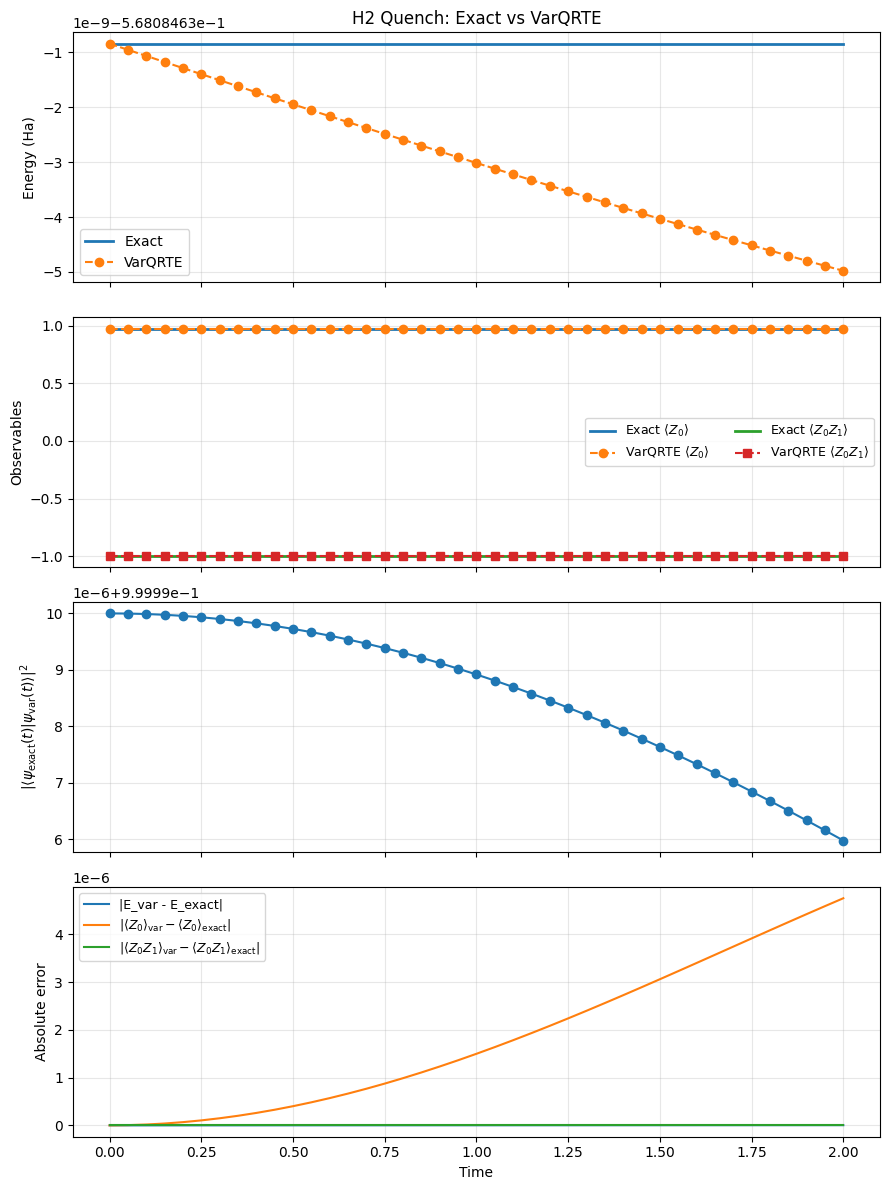

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(9, 12), sharex=True)

axes[0].plot(times, exact_energies, lw=2, label="Exact")
axes[0].plot(times, var_energies, "o--", label="VarQRTE")
axes[0].set_title("H2 Quench: Exact vs VarQRTE")
axes[0].set_ylabel("Energy (Ha)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(times, exact_z0, lw=2, label=r"Exact $\langle Z_0 \rangle$")
axes[1].plot(times, var_z0, "o--", label=r"VarQRTE $\langle Z_0 \rangle$")
axes[1].plot(times, exact_zz01, lw=2, label=r"Exact $\langle Z_0 Z_1 \rangle$")
axes[1].plot(times, var_zz01, "s--", label=r"VarQRTE $\langle Z_0 Z_1 \rangle$")
axes[1].set_ylabel("Observables")
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncol=2, fontsize=9)

axes[2].plot(times, benchmark_fidelity, marker="o")
axes[2].set_ylabel(r"$|\langle \psi_{\mathrm{exact}}(t)|\psi_{\mathrm{var}}(t) \rangle|^2$")
axes[2].grid(True, alpha=0.3)

axes[3].plot(times, energy_error, label="|E_var - E_exact|")
axes[3].plot(times, z0_error, label=r"$|\langle Z_0 \rangle_{\mathrm{var}}-\langle Z_0 \rangle_{\mathrm{exact}}|$")
axes[3].plot(times, zz01_error, label=r"$|\langle Z_0 Z_1 \rangle_{\mathrm{var}}-\langle Z_0 Z_1 \rangle_{\mathrm{exact}}|$")
axes[3].set_xlabel("Time")
axes[3].set_ylabel("Absolute error")
axes[3].grid(True, alpha=0.3)
axes[3].legend(fontsize=9)

plt.tight_layout()
plt.show()
